### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Alan Velasco


**Fecha:** 7/04/2026

## Examen Practico - Segundo Parcial

#### 0) Cargar una de las imágenes histológicas

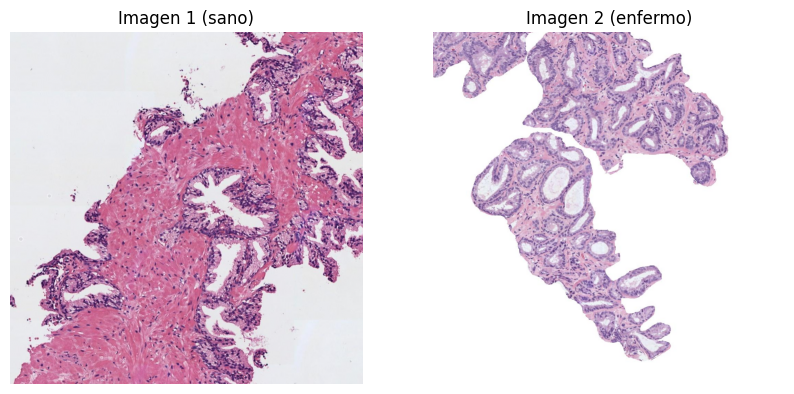

In [1]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label, regionprops
from skimage.segmentation import flood
from scipy import ndimage

# Cargamos y ahcemos que se pueda vizualizarla imagen histológica
rutas = ["histo_1.jpg", "histo_2.jpg"]
titulos = ["Imagen 1 (sano)", "Imagen 2 (enfermo)"]

imagenes = [io.imread(r) for r in rutas]
imagenes = [img_as_float(img) for img in imagenes]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i, img in enumerate(imagenes):
    ax[i].imshow(img)
    ax[i].set_title(titulos[i])
    ax[i].axis("off")
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

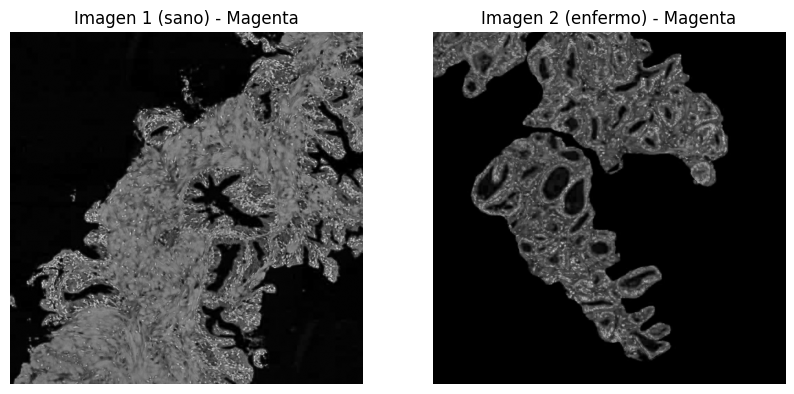

In [10]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta
# cargar imagen en RGB y normalizar al rango [0,1]

#Umbralizarmos para separar fondo + lumen del tejido y convertimos al espacio CMYK para extraer la componente magenta
magentas = []

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, img in enumerate(imagenes):
    # separar canales RGB
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    # calculamos componente K
    K = 1 - np.maximum.reduce([R, G, B])

    # calculamos componente magenta
    M = (1 - G - K) / (1 - K + 1e-8)

    # guardamos
    magentas.append(M)

    # mostramos
    ax[i].imshow(M, cmap="gray")
    ax[i].set_title(f"{titulos[i]} - Magenta")
    ax[i].axis("off")

plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

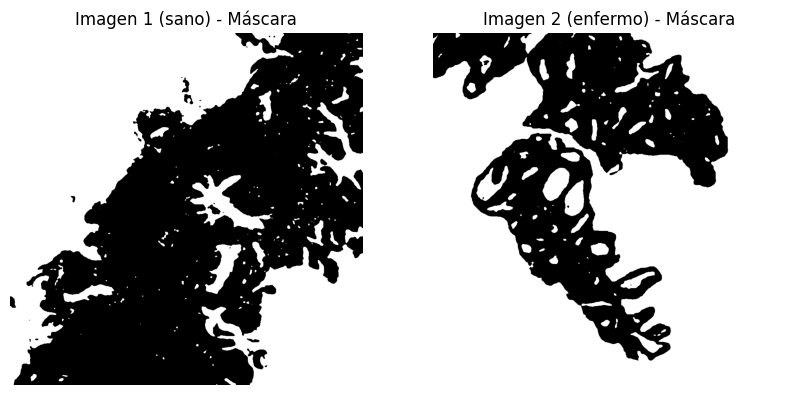

In [3]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

# Umbralizamos  para separar fondo + lumen del tejido

from skimage.filters import threshold_otsu
from scipy.ndimage import gaussian_filter

mascaras = []
fig, ax = plt.subplots(1, len(magentas), figsize=(10,5))

for i, M in enumerate(magentas):
    # convertir a uint8 [0,255]
    M_uint8 = (M * 255).astype(np.uint8)

    # aplicar filtro gaussiano 5x5 
    suavizada = gaussian_filter(M_uint8, sigma=2)

    # calculamos umbral de Otsu
    t = threshold_otsu(suavizada)

    # máscara binaria: lumen + fondo = 1, resto = 0
    mask = (suavizada < t).astype(np.uint8)

    mascaras.append(mask)

    ax[i].imshow(mask, cmap="gray")
    ax[i].set_title(f"{titulos[i]} - Máscara")
    ax[i].axis("off")

plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

C:\Users\admin\AppData\Local\Temp\ipykernel_9488\3248218274.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  limpia = remove_small_objects(mask.astype(bool), min_size=300)


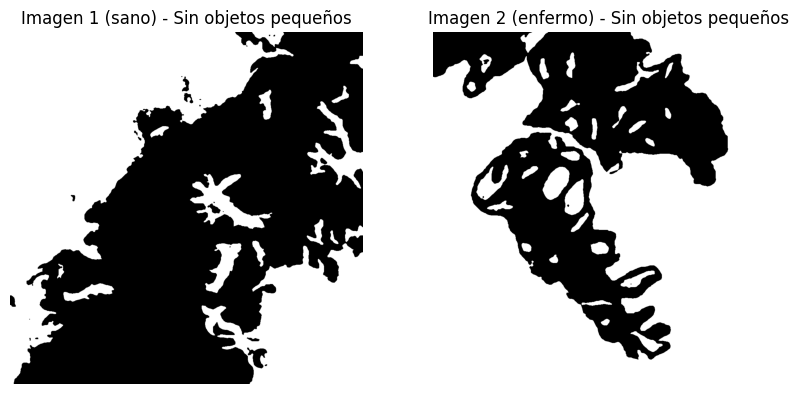

In [4]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

from skimage.morphology import remove_small_objects

limpias = []

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, mask in enumerate(mascaras):
    # eliminar objetos blancos pequeños
    limpia = remove_small_objects(mask.astype(bool), min_size=300)

    limpias.append(limpia)

    ax[i].imshow(limpia, cmap="gray")
    ax[i].set_title(f"{titulos[i]} - Sin objetos pequeños")
    ax[i].axis("off")

plt.show()


#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

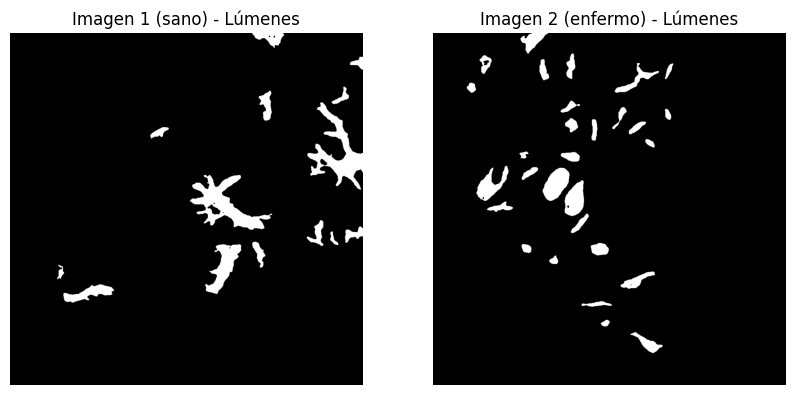

In [5]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 
from skimage.segmentation import flood

lumenes = []

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, img in enumerate(limpias):
    # copiamos la máscara
    fondo = img.copy()

    # usar dos semillas en esquinas para detectar el fondo
    semilla1 = (0, 0)
    semilla2 = (img.shape[0]-1, img.shape[1]-1)

    # region growing desde las semillas
    fondo1 = flood(img, semilla1)
    fondo2 = flood(img, semilla2)

    # unir ambas regiones de fondo
    fondo_total = fondo1 | fondo2

    # invertimos, quitamos fondo y dejamos solo lúmenes
    solo_lumen = img & (~fondo_total)

    lumenes.append(solo_lumen)

    ax[i].imshow(solo_lumen, cmap="gray")
    ax[i].set_title(f"{titulos[i]} - Lúmenes")
    ax[i].axis("off")

plt.show()

#### 5) Rellenar los objetos de los lúmenes

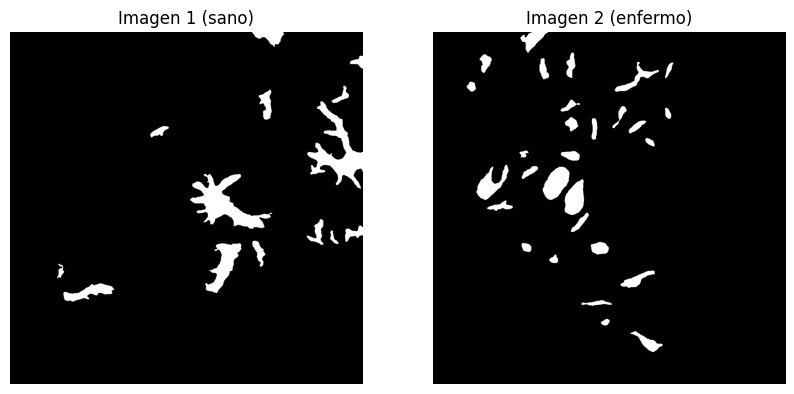

In [6]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

#utilizamos la funcion binary_fill_holes para rellenar huecosdentro de objetos en una imagen binaria.
from scipy.ndimage import binary_fill_holes

# creamos una lista para guardar los lúmenes rellenos
rellenos = []

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, lumen in enumerate(lumenes):

    # rellenamos huecos dentro de las regiones binarias
    fill = binary_fill_holes(lumen)

    # guardamos resultado
    rellenos.append(fill)

    # Mostramos la imagen
    ax[i].imshow(fill, cmap="gray")
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()


#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

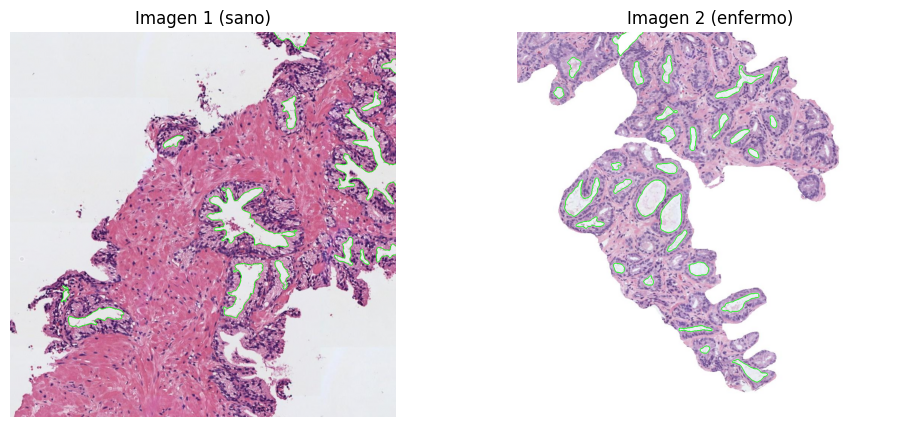

In [7]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries #esta funcion sirve para dibujar los bordes  de regiones segmentadas sobre una imagen original

fig, ax = plt.subplots(1, len(rellenos), figsize=(12,5))

for i, relleno in enumerate(rellenos):
    # superponer contornos en verde sobre la imagen original
    salida = mark_boundaries(imagenes[i], relleno, color=(0,1,0), mode='thick')

    ax[i].imshow(salida)
    ax[i].set_title(titulos[i])
    ax[i].axis("off")

plt.show()

#### 7) Identificar y cropear el lumen más grande

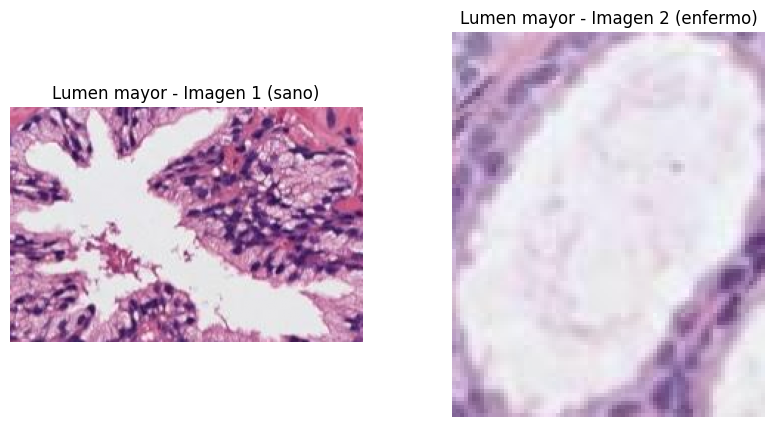

In [8]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops #estas funciones se usan para analizar objetos dentro de una imagen binaria

fig, ax = plt.subplots(1, len(rellenos), figsize=(10,5))

for i, img in enumerate(rellenos):
    # etiquetar regiones conectadas
    etiquetas = label(img)

    # obtener propiedades de cada región
    props = regionprops(etiquetas)

    # calculamos áreas y encontrar índice de la mayor
    areas = [r.area for r in props]
    idx_max = np.argmax(areas)
    mayor = props[idx_max]

    # bounding box del lumen más grande
    minr, minc, maxr, maxc = mayor.bbox

    # recortar sobre la imagen original
    crop = imagenes[i][minr:maxr, minc:maxc]

    # mostramos resultado
    ax[i].imshow(crop)
    ax[i].set_title(f"Lumen mayor - {titulos[i]}")
    ax[i].axis("off")

plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [9]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.

import numpy as np
from skimage.measure import label, regionprops
from math import pi

# ejemplo con un lumen recortado de mayor área
for i, img in enumerate(rellenos):
    etiquetas = label(img)
    props = regionprops(etiquetas)

    if not props:
        continue

    # seleccionamos la región de mayor área
    mayor = max(props, key=lambda x: x.area)

    # calcular métricas
    caracteristicas = {
        "Área": mayor.area,
        "Área bounding box": mayor.bbox_area,
        "Área convexa": mayor.convex_area,
        "Excentricidad": mayor.eccentricity,
        "Diámetro equivalente": mayor.equivalent_diameter,
        "Extensión": mayor.extent,
        "Long eje mayor": mayor.major_axis_length,
        "Long eje menor": mayor.minor_axis_length,
        "Orientación": mayor.orientation,
        "Perímetro": mayor.perimeter,
        "Solidez": mayor.solidity,
    }

    # métricas derivadas
    minr, minc, maxr, maxc = mayor.bbox
    feret = np.sqrt((maxr-minr)**2 + (maxc-minc)**2)
    caracteristicas["Diámetro Feret"] = feret

    compacidad = (mayor.perimeter**2) / (4*pi*mayor.area)
    caracteristicas["Compacidad"] = compacidad

    # redondear a 4 decimales
    caracteristicas_redondeadas = {k: round(v,4) for k,v in caracteristicas.items()}

    print(f"Imagen {i} - {titulos[i]}")
    for k,v in caracteristicas_redondeadas.items():
        print(f"{k}: {v}")
    print("-"*40)

Imagen 0 - Imagen 1 (sano)
Área: 13849.0
Área bounding box: 38240.0
Área convexa: 28259.0
Excentricidad: 0.8459
Diámetro equivalente: 132.7897
Extensión: 0.3622
Long eje mayor: 235.6416
Long eje menor: 125.666
Orientación: 0.9966
Perímetro: 1131.2357
Solidez: 0.4901
Diámetro Feret: 287.6126
Compacidad: 7.3532
----------------------------------------
Imagen 1 - Imagen 2 (enfermo)
Área: 4805.0
Área bounding box: 7488.0
Área convexa: 4938.0
Excentricidad: 0.8381
Diámetro equivalente: 78.2171
Extensión: 0.6417
Long eje mayor: 106.1532
Long eje menor: 57.9115
Orientación: -0.5607
Perímetro: 277.8061
Solidez: 0.9731
Diámetro Feret: 123.6932
Compacidad: 1.2781
----------------------------------------


C:\Users\admin\AppData\Local\Temp\ipykernel_9488\422121927.py:21: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  "Área bounding box": mayor.bbox_area,
C:\Users\admin\AppData\Local\Temp\ipykernel_9488\422121927.py:22: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  "Área convexa": mayor.convex_area,
C:\Users\admin\AppData\Local\Temp\ipykernel_9488\422121927.py:24: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  "Diámetro equivalente": mayor.equivalent_diameter,
C:\Users\admin\AppData\Local\Temp\ipykernel_9488\422121927.py:26: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 

**Repositorio: https://github.com/ALAN-SVV/ExamenPracticoP2.git**